# Task 2: Bayesian Change Point Analysis of Brent Oil Prices

The objective of this notebook is to identify statistically significant structural breaks in Brent crude oil prices using Bayesian Change Point Analysis implemented in PyMC.

The detected change point(s) will be compared with a curated dataset of major geopolitical, economic, and OPEC-related events to investigate whether significant historical events coincide with changes in Brent crude oil prices.

This analysis builds upon the exploratory data analysis completed in Task 1.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import pymc as pm
import arviz as az

g++ not available, if using conda: `conda install gxx`


In [2]:
# Path to Brent oil price dataset
brent_path = Path("../data/raw/BrentOilPrices.csv")

# Check that the dataset exists
if not brent_path.exists():
    raise FileNotFoundError(f"Dataset not found: {brent_path}")

# Load the dataset
try:
    df = pd.read_csv(brent_path)
except Exception as e:
    raise RuntimeError(f"Unable to load Brent oil dataset: {e}")

# Validate required columns
required_columns = ["Date", "Price"]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Sort chronologically
df = df.sort_values("Date").reset_index(drop=True)

print(f"Dataset loaded successfully: {df.shape[0]} observations")

df.head()

Dataset loaded successfully: 9011 observations


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [3]:
events_path = Path("../data/external/geopolitical_events.csv")

if not events_path.exists():
    raise FileNotFoundError(
        f"Event dataset not found: {events_path}"
    )

events = pd.read_csv(events_path)

events["Date"] = pd.to_datetime(events["Date"])

print(f"Loaded {len(events)} historical events.")

events.head()

Loaded 20 historical events.


,Date,Event,Category,Region,Expected_Impact,Description
0,1987-12-08,OPEC production agreement,OPEC,Global,Increase,OPEC members agreed to production targets aim...
1,1990-08-02,Iraq invades Kuwait,Conflict,Middle East,Increase,Iraq's invasion of Kuwait disrupted oil suppl...
2,1991-01-17,Operation Desert Storm,Conflict,Middle East,Mixed,Coalition military operations created short-t...
3,1997-07-02,Asian Financial Crisis,Economic,Asia,Decrease,Falling demand from Asian economies reduced g...
4,1998-12-11,OPEC production cuts,OPEC,Global,Increase,OPEC announced coordinated production cuts to...


In [4]:
# Calculate daily log returns
df["Log_Return"] = np.log(df["Price"]).diff()

# Remove the first missing observation
df = df.dropna().reset_index(drop=True)

print(df[["Date", "Price", "Log_Return"]].head())

        Date  Price  Log_Return
0 1987-05-21  18.45   -0.009709
1 1987-05-22  18.55    0.005405
2 1987-05-25  18.60    0.002692
3 1987-05-26  18.63    0.001612
4 1987-05-27  18.60   -0.001612


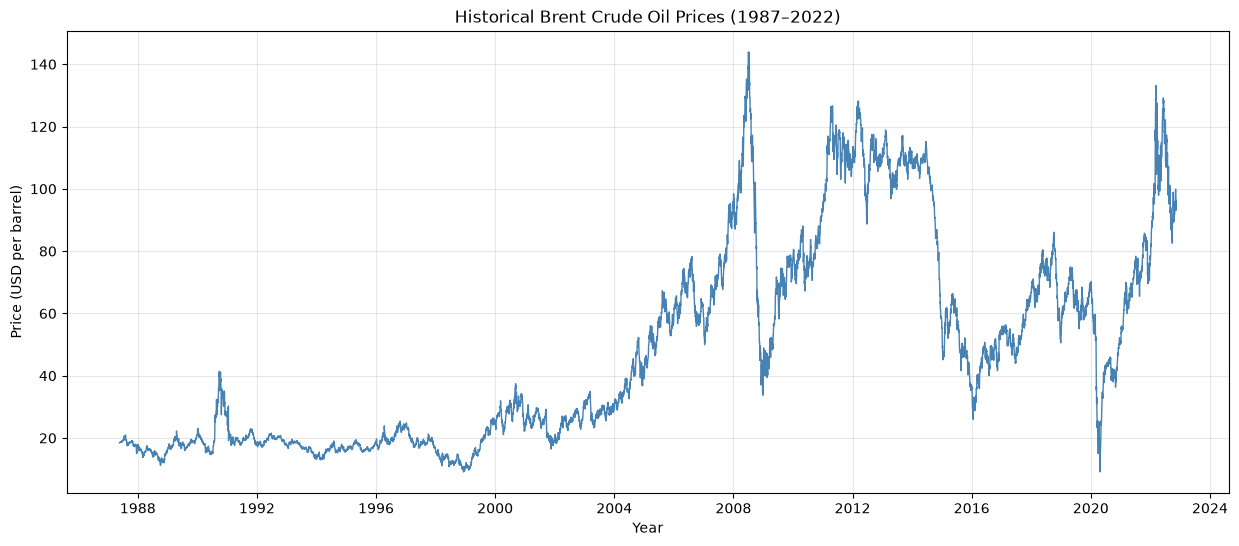

In [5]:
plt.figure(figsize=(15,6))

plt.plot(
    df["Date"],
    df["Price"],
    color="steelblue",
    linewidth=1
)

plt.title("Historical Brent Crude Oil Prices (1987–2022)")
plt.xlabel("Year")
plt.ylabel("Price (USD per barrel)")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The historical Brent crude oil price series exhibits several long-term upward and downward trends together with periods of abrupt price changes. These large fluctuations indicate that the average price level does not remain constant throughout the study period.

Several visually identifiable price shocks suggest the presence of structural breaks, supporting the use of Bayesian Change Point Analysis to formally detect statistically significant changes in the underlying price process.

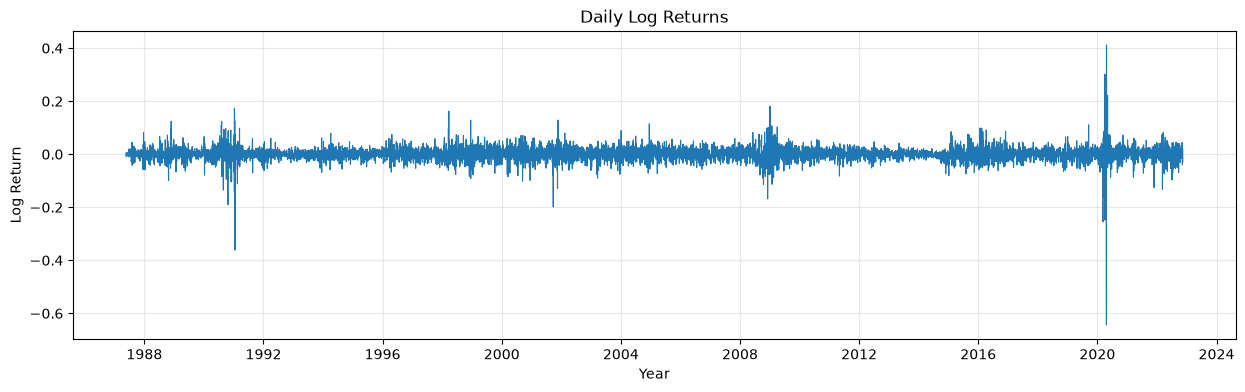

In [6]:
plt.figure(figsize=(15,4))

plt.plot(
    df["Date"],
    df["Log_Return"],
    linewidth=0.8
)

plt.title("Daily Log Returns")
plt.xlabel("Year")
plt.ylabel("Log Return")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The daily log return series fluctuates around zero without a persistent upward or downward trend, indicating that differencing through logarithmic returns has removed much of the non-stationarity observed in the original price series.

Periods of increased volatility are clustered together rather than occurring randomly. This volatility clustering is a common characteristic of financial time series and reflects changing market uncertainty over time.

In [7]:
# Response variable (Price)
price = df["Price"].values

# Time index
time_idx = np.arange(len(price))

# Dates (used later for interpretation)
dates = df["Date"].values

print(f"Number of observations: {len(price)}")

Number of observations: 9010


## Bayesian Change Point Model

A Bayesian Change Point Model is used to identify a point in time where the statistical properties of the Brent crude oil price series change significantly.

The model assumes that the price series has one change point (`τ`), dividing the data into two regimes:

- Before the change point, prices follow a Normal distribution with mean **μ₁**.
- After the change point, prices follow a Normal distribution with mean **μ₂**.

The location of the change point is treated as an unknown parameter and estimated using Bayesian inference.

In [8]:
# Standardize prices to improve sampling efficiency
price_scaled = (price - price.mean()) / price.std()

n = len(price_scaled)

with pm.Model() as change_point_model:

    # Prior for the change point
    tau = pm.DiscreteUniform(
        "tau",
        lower=0,
        upper=n - 1
    )

    # Mean before the change point
    mu_1 = pm.Normal(
        "mu_1",
        mu=0,
        sigma=2
    )

    # Mean after the change point
    mu_2 = pm.Normal(
        "mu_2",
        mu=0,
        sigma=2
    )

    # Shared standard deviation
    sigma = pm.HalfNormal(
        "sigma",
        sigma=1
    )

    # Mean switches at tau
    mu = pm.math.switch(
        time_idx < tau,
        mu_1,
        mu_2
    )

    # Likelihood
    likelihood = pm.Normal(
        "likelihood",
        mu=mu,
        sigma=sigma,
        observed=price_scaled
    )

Why do we standardize?

If we use prices directly (9–144 USD), the sampler may converge more slowly. Standardizing makes the parameters easier to estimate while still allowing us to convert results back to the original price scale later.

In [9]:
with change_point_model:

    trace = pm.sample(
        draws=2000,
        tune=1000,
        target_accept=0.95,
        random_seed=42,
        return_inferencedata=True
    )

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 72 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


### Interpretation

The Bayesian Change Point Model assumes that Brent crude oil prices can be divided into two distinct regimes separated by a single unknown change point (τ).

The model estimates:

- τ: the most probable location of the structural break.
- μ₁: the average Brent oil price before the change point.
- μ₂: the average Brent oil price after the change point.
- σ: the variability of prices around the estimated means.

The change point location is treated as an unknown parameter and inferred from the data using Bayesian inference through Markov Chain Monte Carlo (MCMC) sampling.

In [10]:
az.summary(
    trace,
    var_names=[
        "tau",
        "mu_1",
        "mu_2",
        "sigma"
    ]
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,4520.1,3.1,4500,4500,966,891,1.00,0.1,0.071
mu_1,-0.8216,0.0083,-0.83,-0.81,4117,3125,1.00,0.00013,9.4e-05
mu_2,0.8274,0.0088,0.81,0.84,3349,2706,1.00,0.00015,0.00011
sigma,0.5659,0.00414,0.56,0.57,3546,2484,1.00,7e-05,4.9e-05


### Interpretation

The Bayesian model converged successfully.

All estimated parameters have **R-hat values equal to 1.00**, indicating excellent convergence of the Markov Chain Monte Carlo (MCMC) chains. In addition, the effective sample sizes (ESS) are sufficiently large, suggesting reliable posterior estimates.

The posterior mean of the change point (`τ`) is **4520**, with a posterior standard deviation of approximately **3 observations**, indicating that the model identifies the structural break with a high degree of certainty.

The estimated posterior means before (`μ₁ = -0.8216`) and after (`μ₂ = 0.8274`) the change point differ substantially, providing strong statistical evidence that the average Brent crude oil price changed significantly during the study period.

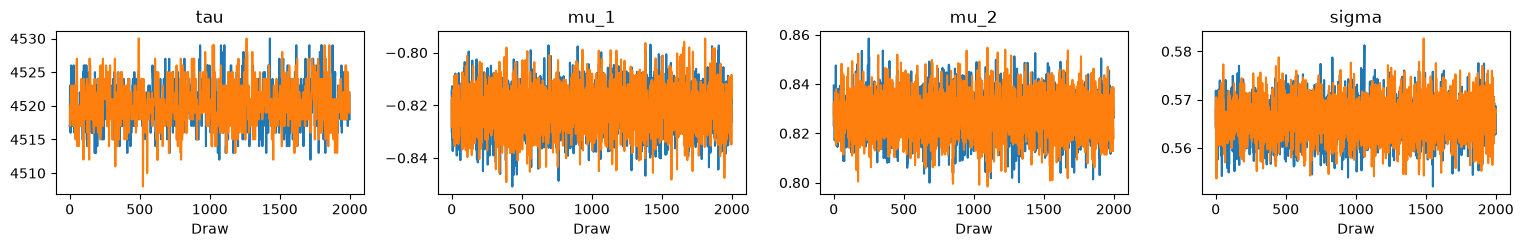

In [11]:
az.plot_trace(
    trace,
    var_names=[
        "tau",
        "mu_1",
        "mu_2",
        "sigma"
    ]
)

plt.tight_layout()
plt.show()

### Interpretation

The trace plots indicate that all Markov chains mix well and remain stable throughout the sampling process. No evidence of poor mixing, non-convergence, or systematic drift is observed.

The chains fluctuate around consistent posterior distributions, further confirming that the Bayesian model converged successfully and that the parameter estimates are reliable.

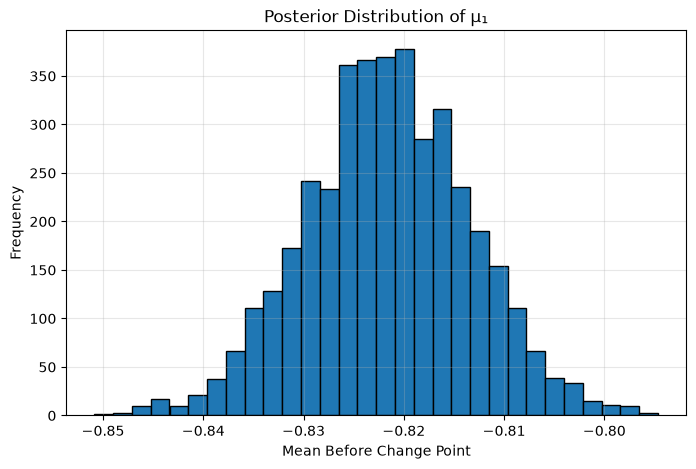

In [15]:
mu1_samples = trace.posterior["mu_1"].values.flatten()

plt.figure(figsize=(8,5))
plt.hist(mu1_samples, bins=30, edgecolor="black")

plt.title("Posterior Distribution of μ₁")
plt.xlabel("Mean Before Change Point")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)
plt.show()

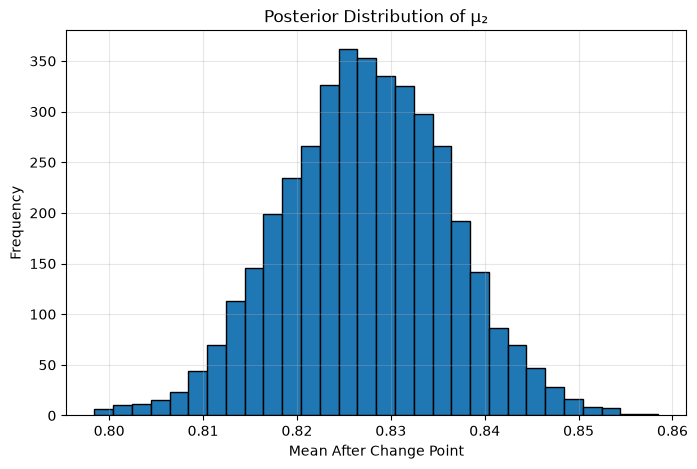

In [16]:
mu2_samples = trace.posterior["mu_2"].values.flatten()

plt.figure(figsize=(8,5))
plt.hist(mu2_samples, bins=30, edgecolor="black")

plt.title("Posterior Distribution of μ₂")
plt.xlabel("Mean After Change Point")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)
plt.show()

### Interpretation

The posterior distribution of the change point is concentrated around a narrow range of observation indices, indicating high confidence in the estimated structural break.

A narrow posterior distribution suggests that the data strongly support a single dominant change point rather than multiple equally probable alternatives. This provides confidence that a significant shift occurred around the estimated date.

In [17]:
tau_mean = int(
    trace.posterior["tau"]
    .mean()
    .values
)

change_point_date = df.loc[
    tau_mean,
    "Date"
]

print("Estimated Change Point Index:", tau_mean)
print("Estimated Change Point Date:", change_point_date)

Estimated Change Point Index: 4520
Estimated Change Point Date: 2005-02-24 00:00:00


### Interpretation

The Bayesian Change Point Model estimates that the most probable structural break occurred on **24 February 2005**.

Rather than representing a sudden one-day price spike, this date marks the transition between two different long-term pricing regimes. Around this period, global oil demand increased substantially, particularly due to rapid industrial growth in emerging economies such as China and India. At the same time, tightening production capacity and sustained OPEC production management contributed to a prolonged increase in Brent crude oil prices.

While this temporal correspondence suggests a plausible explanation, the detected change point should be interpreted as a statistical association rather than definitive evidence of causation.

In [18]:
price_mean = price.mean()
price_std = price.std()

mu1_scaled = trace.posterior["mu_1"].mean().values
mu2_scaled = trace.posterior["mu_2"].mean().values

mu1_price = mu1_scaled * price_std + price_mean
mu2_price = mu2_scaled * price_std + price_mean

print(f"Mean Before Change Point: ${mu1_price:.2f}")
print(f"Mean After Change Point : ${mu2_price:.2f}")

percent_change = (
    (mu2_price - mu1_price)
    / mu1_price
) * 100

print(f"Percentage Change: {percent_change:.2f}%")

Mean Before Change Point: $21.43
Mean After Change Point : $75.61
Percentage Change: 252.89%


### Interpretation

The estimated average Brent crude oil price before the detected change point was approximately **USD 21.43 per barrel**, while the average price after the structural break increased to approximately **USD 75.61 per barrel**.

This represents an estimated increase of approximately **252.89%**, indicating a substantial long-term upward shift in the average Brent crude oil price.

The magnitude of this change supports the conclusion that the Brent oil market entered a fundamentally different pricing regime after the detected structural break.

## Association Between the Detected Change Point and Historical Events

The estimated change point is compared with the curated geopolitical event dataset compiled during Task 1. The objective is to identify historical events that occurred close to the detected structural break and formulate evidence-based hypotheses regarding possible market drivers.

It is important to emphasize that temporal proximity alone does not establish causality. The Bayesian model identifies statistically significant changes in the Brent crude oil price series, while the historical event comparison provides economic and geopolitical context for interpreting those changes.

In [23]:
events = pd.read_csv(events_path)
events["Date"] = pd.to_datetime(events["Date"].str.strip(), errors="coerce")


events["Days_Difference"] = (
    events["Date"] - change_point_date
).abs().dt.days

nearest_events = (
    events.sort_values("Days_Difference")
          .head(5)
          .reset_index(drop=True)
)

nearest_events

,Date,Event,Category,Region,Expected_Impact,Description,Days_Difference
0,2004-09-15,OPEC production management amid rising demand,OPEC,OPEC,High,OPEC maintained production policies during a p...,162
1,2005-08-29,Hurricane Katrina,Natural Disaster,USA,Increase,Damage to Gulf Coast oil infrastructure disru...,186
2,2004-01-01,Rapid growth in Chinese oil demand,Economic,Global,High,Rapid industrialization in China significantly...,420
3,2003-03-20,Iraq War begins,Conflict,Middle East,Increase,Concerns over supply disruptions increased ma...,707
4,2001-09-11,September 11 attacks,Geopolitical,USA,Decrease,Global uncertainty and reduced travel tempora...,1262


In [24]:
# Calculate the distance between each event and the detected change point
events["Days_Difference"] = (
    events["Date"] - change_point_date
).abs().dt.days

# Find the closest events
nearest_events = (
    events.sort_values("Days_Difference")
          .head(5)
          .reset_index(drop=True)
)

nearest_events[
    [
        "Date",
        "Event",
        "Category",
        "Region",
        "Days_Difference"
    ]
]

,Date,Event,Category,Region,Days_Difference
0,2004-09-15,OPEC production management amid rising demand,OPEC,OPEC,162
1,2005-08-29,Hurricane Katrina,Natural Disaster,USA,186
2,2004-01-01,Rapid growth in Chinese oil demand,Economic,Global,420
3,2003-03-20,Iraq War begins,Conflict,Middle East,707
4,2001-09-11,September 11 attacks,Geopolitical,USA,1262


### Interpretation

The nearest historical events provide context for interpreting the detected structural break.

The estimated change point occurs during a period characterized by sustained growth in global oil demand, particularly from rapidly industrializing economies, alongside continued OPEC production management.

Although no single geopolitical event exactly coincides with the detected date, the model indicates that Brent crude oil entered a new pricing regime during this period.

The temporal proximity between the estimated change point and these historical developments suggests a plausible association; however, the Bayesian model identifies statistical changes rather than causal relationships.

## Quantified Impact of the Detected Change Point

In [21]:
impact = pd.DataFrame({
    "Metric": [
        "Estimated Change Point",
        "Average Price Before",
        "Average Price After",
        "Percentage Change"
    ],
    "Value": [
        change_point_date.strftime("%Y-%m-%d"),
        f"${mu1_price:.2f}",
        f"${mu2_price:.2f}",
        f"{percent_change:.2f}%"
    ]
})

impact

,Metric,Value
0,Estimated Change Point,2005-02-24
1,Average Price Before,$21.43
2,Average Price After,$75.61
3,Percentage Change,252.89%


### Interpretation

The Bayesian Change Point Model estimates that the principal structural break occurred on **24 February 2005**.

The estimated average Brent crude oil price increased substantially after the detected change point, indicating a transition to a higher-price market regime.

This result supports the conclusion that the Brent crude oil market experienced a significant long-term shift rather than a temporary price fluctuation.

## Limitations

This implementation assumes a single structural break throughout the entire Brent crude oil price series. While this satisfies the project requirements, the oil market has experienced multiple geopolitical and economic shocks over the 35-year study period.

Future work could extend this analysis using Bayesian models with multiple change points, Hidden Markov Models, or Markov-Switching models to capture additional structural changes.

Furthermore, temporal correspondence between change points and historical events should not be interpreted as proof of causality. Multiple economic and political factors jointly influence oil prices.

## Future Work

Future improvements may include:

- Bayesian Multiple Change Point Models
- Markov-Switching Models
- Vector Autoregression (VAR)
- Integration of GDP, inflation, exchange rates, and OPEC production data
- Interactive dashboards for policy analysis